# IMPORTS

In [1]:
%load_ext autoreload

import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax.numpy as jnp

import tol_colors as tc
import matplotlib.pyplot as plt
import plotting_tools.basic_plotting_tools as pts
colors = pts.set_plot_style(default_cmap=tc.sunset)
%matplotlib widget

In [2]:
import differential_geometry.manifolds as manifolds
import differential_geometry.aux_manifolds as aux_manifolds
import plotting_tools.plot_manifolds as plot_manifolds

from scipy.spatial import Delaunay
import differential_geometry.charts as charts
import differential_geometry.aux_charts as aux_charts
import plotting_tools.plot_charts as plot_charts

import differential_geometry.functions as functions
import plotting_tools.plot_functions as plot_functions

# 2D-mfd embedded in 3D

In [3]:
manifold = manifolds.Manifold(
    name=r"$\mathcal{M}$", dim=2, ambient_dim=3,
    embedding_func=aux_manifolds.factory_surface_embedding_gaussian_eggs(amplitude=1.0, center=(0.0, 0.0), sigma=(jnp.pi, jnp.pi)),
)

# === Define Charts as intervals in param space ===
center_V = jnp.array([0.7, 0.3])
axes_V = (1.4, 0.9)
x_center_polar, y_center_polar = -1., -1.

# center_V = jnp.array([0.0, 0.0])
# axes_V = (jnp.pi / 3, jnp.pi / 3)
# x_center_polar, y_center_polar = 0.0, 0.0

polar_center = (x_center_polar, y_center_polar)
lambdas = jnp.linspace(0, 2 * jnp.pi, 600)
boundary_V = aux_charts.boundary_ellipse_in_param_space(lambdas, center=center_V, axes=axes_V)
chart_V = charts.Chart(
    name="V", manifold=manifold, boundary=jnp.array(boundary_V),
    chart_map=lambda params: aux_charts.polar_chart_map(params, center=polar_center),
    inverse_chart_map=lambda chart_coords: aux_charts.inverse_polar_chart_map(chart_coords, center=polar_center),
    region_sampler=aux_charts.polar_region_sampler_from_boundary(jnp.array(boundary_V), center=jnp.array(polar_center))
)


center_U = jnp.array([0.1, -0.7])
axes_U = (0.9, 1.5)
boundary_U = aux_charts.boundary_ellipse_in_param_space(lambdas, center=center_U, axes=axes_U)

# lambdas = jnp.linspace(0, 4, 500, endpoint=False)
# boundary_U = charts.boundary_rectangle_in_param_space(
#     lambdas, xlim=(-jnp.pi / 3, jnp.pi / 3), ylim=(-jnp.pi / 3, jnp.pi / 3)
# )

chart_U = charts.Chart(
    name="U", manifold=manifold, boundary=jnp.array(boundary_U),
    chart_map=aux_charts.cartesian_chart_map,
    inverse_chart_map=aux_charts.inverse_cartesian_chart_map,
    region_sampler=aux_charts.polar_region_sampler_from_boundary(
        jnp.array(boundary_U), center=jnp.array(polar_center)
    )
)


boundary_U_cap_V = aux_charts.compute_chart_intersection(boundary_U, boundary_V)

chart_U_cap_V_X = charts.Chart(
    name="U_cap_V_X", manifold=manifold, boundary=jnp.array(boundary_U_cap_V),
    chart_map=aux_charts.cartesian_chart_map,
    inverse_chart_map=aux_charts.inverse_cartesian_chart_map,
    region_sampler=aux_charts.polar_region_sampler_from_boundary(
        jnp.array(boundary_U_cap_V), center=jnp.array(polar_center)
    )
)

chart_U_cap_V_Y = charts.Chart(
    name="U_cap_V_Y", manifold=manifold, boundary=jnp.array(boundary_U_cap_V),
    chart_map=lambda params: aux_charts.polar_chart_map(params, center=polar_center),
    inverse_chart_map=lambda chart_coords: aux_charts.inverse_polar_chart_map(chart_coords, center=polar_center),
    region_sampler=aux_charts.polar_region_sampler_from_boundary(
        jnp.array(boundary_U_cap_V), center=jnp.array(polar_center)
    )
)


def my_function(params):
    x, y = params
    param_points = jnp.stack([x.ravel(), y.ravel()], axis=-1)
    tmp_ = manifold.embed(param_points)
    tmp_x = tmp_[:, 0].reshape(x.shape)
    tmp_y = tmp_[:, 1].reshape(y.shape)
    tmp_z = tmp_[:, 2].reshape(x.shape)
    return tmp_z  * jnp.sqrt(tmp_x**2 + tmp_y**2 + 2.)

function_f = functions.Function(
    manifold=manifold,
    function_parametric=my_function
)

ERROR:2026-09-24 16:56:17,250:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/dlopez/.miniconda3/envs/diff_geom/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 197, in _version_check
    version = get_version()
RuntimeError: jaxlib/cuda/versions_helpers.cc:81: operation cusparseGetProperty(MAJOR_VERSION, &major) failed: The cuSPARSE library was not found.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/home/dlopez/.miniconda3/envs/diff_geom/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/dlopez/.miniconda3/envs/diff_geom/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/dlopez/.miniconda3/envs/

## plot mfd

/home/dlopez/tmp/pip-tmp/ipykernel_524811/2604966071.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


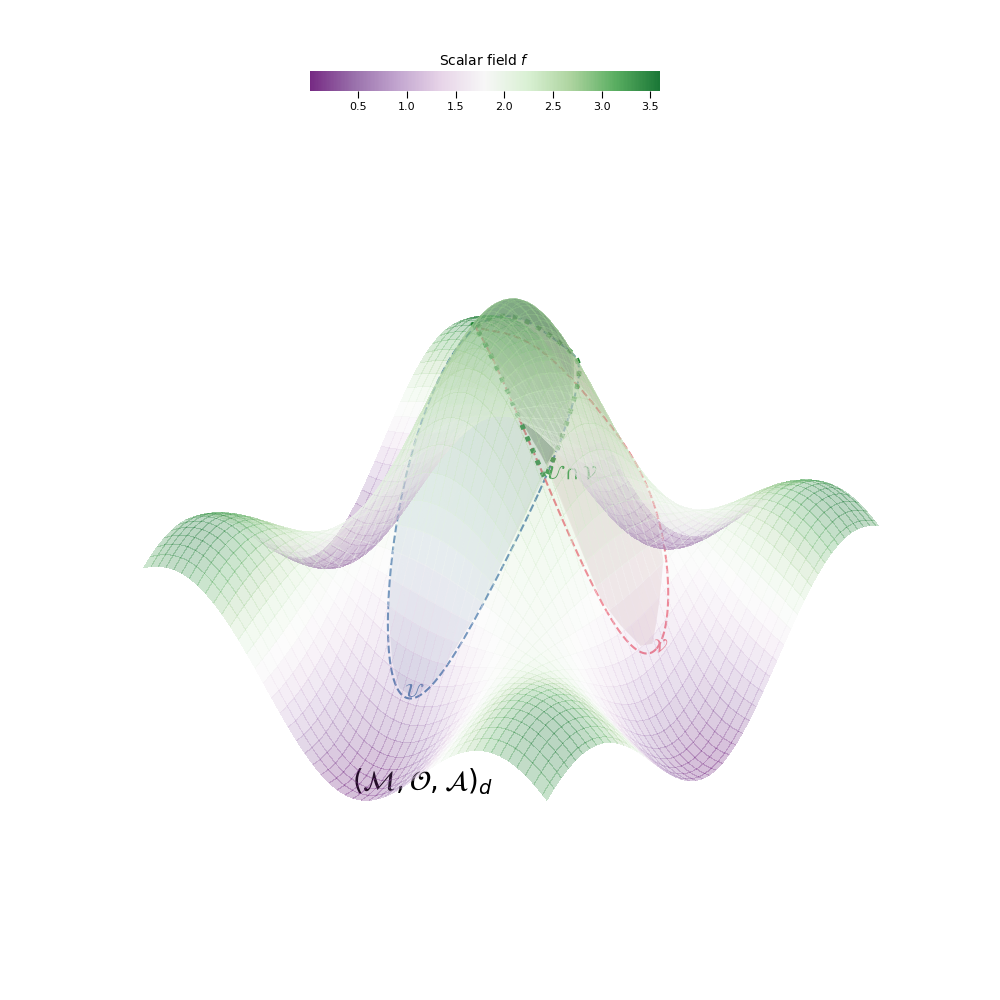

In [4]:
xmin, xmax = jnp.array([-jnp.pi, jnp.pi]) * jnp.pi/3
ymin, ymax = jnp.array([-jnp.pi, jnp.pi]) * jnp.pi/3

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

plot_manifolds.plot_manifold(
    ax=ax, manifold=manifold, resolution=100, xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
    color=colors[-1], alpha=0.3, edgecolor="none", label=r"$\left(\mathcal{M}, \mathcal{O}, \mathcal{A}\right)_d$",
    label_position="bottom", label_fontsize=20, function=function_f, cmap=tc.PRGn,
    label_function="Scalar field $f$", inset_colorbar=True, inset_position=(0.3, 0.93), inset_size=(3.5, 0.2),
    colorbar_orientation="horizontal", label_colorbar_position="top",
    inset_box_alpha=0.8, inset_box_color="white", inset_border_color="black"
)

plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=manifold, chart=chart_U,
    color=colors[0], n_points=2**11, linestyle="dashed", linewidth=1.5,
    fill_surface=True, alpha=0.15, edgecolor=None, linewidth_fill=0.5,
    label=r"$\mathcal{U}$", label_position="bottom", label_fontsize=14,
    draw_endpoints=True, endpoint_color=colors[0], endpoint_size=30,
)
plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=manifold, chart=chart_V,
    color=colors[1], n_points=2**12, linestyle="dashed", linewidth=1.5,
    fill_surface=True, alpha=0.15, edgecolor=None, linewidth_fill=0.5,
    label=r"$\mathcal{V}$", label_position="bottom", label_fontsize=14,
    draw_endpoints=True, endpoint_color=colors[1], endpoint_size=30,
)
plot_charts.plot_chart_region_manifold(
    ax=ax, surface_manifold=manifold, chart=chart_U_cap_V_X,
    color=colors[2], n_points=2**12, linestyle="dotted", linewidth=3.5,
    fill_surface=True, alpha=0.3, edgecolor=None, linewidth_fill=0.5,
    label=r"$\mathcal{U} \cap \mathcal{V}$", label_position="bottom", label_fontsize=14,
    draw_endpoints=True, endpoint_color=colors[2], endpoint_size=30,
)

ax.view_init(elev=40.0, azim=-50.0)
ax.set_box_aspect([1, 1, 0.8])
plt.tight_layout()
plt.show()

## Chart $(\mathcal{U}, \mathcal{X})$

/home/dlopez/tmp/pip-tmp/ipykernel_524811/2100654845.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


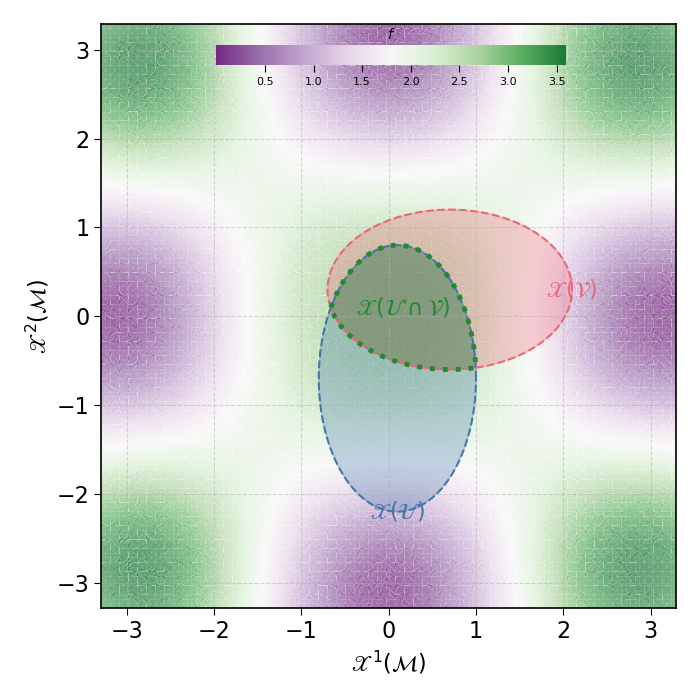

In [5]:
fig, ax = plt.subplots(figsize=(7, 7))

x = jnp.linspace(xmin, xmax, 128)
y = jnp.linspace(ymin, ymax, 128)
x, y = jnp.meshgrid(x, y)
param_points = jnp.stack([x.ravel(), y.ravel()], axis=-1)
param_points = jnp.array(param_points)
# param_points = jnp.array(chart_U.sample_region_in_param_space(n_points=2**13))
function_values = jnp.array(function_f.evaluate_in_param_space(param_points))
tri = Delaunay(param_points)
plot_functions.plot_parametric_function_in_chart_coordinates(
    ax=ax, chart=chart_U, param_space_data=param_points, function_values=function_values, cmap=tc.PRGn,
    alpha=0.7, linewidth=0.01, label=None, label_position="top", label_fontsize=16,
    simplices=tri.simplices, inset_colorbar=True, inset_position=(0.2, 0.93), inset_size=(3.5, 0.2),
    colorbar_orientation="horizontal", label_colorbar=r"$f$", label_colorbar_position="top",
    inset_box_alpha=1.0, inset_box_color="white", inset_border_color="black"
)

plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_U, param_space_data=chart_U.boundary_curve, color=colors[0], linestyle="dashed",
    linewidth=1.5, alpha=0.3, label=r"$\mathscr{X}(\mathcal{U})$", label_position="bottom",
    label_fontsize=16, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color=colors[0], boundary_marker_size=8
)
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_U, param_space_data=chart_V.boundary_curve, color=colors[1], linestyle="dashed",
    linewidth=1.5, alpha=0.3, label=r"$\mathscr{X}(\mathcal{V})$", label_position="right",
    label_fontsize=16, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color=colors[1], boundary_marker_size=8
)
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_U, param_space_data=chart_U_cap_V_X.boundary_curve, color=colors[2], linestyle="dotted",
    linewidth=3.5, alpha=0.3, label=r"$\mathscr{X}(\mathcal{U} \cap \mathcal{V})$", label_position="center",
    label_fontsize=16, tessellated=False, simplices=None, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color=colors[2], boundary_marker_size=8
)

ax.set(xlim=(xmin, xmax), ylim=(ymin, ymax), xlabel=r"$\mathscr{X}^1\left( \mathcal{M} \right)$", ylabel=r"$\mathscr{X}^2\left( \mathcal{M} \right)$")
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Chart $(\mathcal{V}, \mathcal{Y})$

/home/dlopez/tmp/pip-tmp/ipykernel_524811/2545784112.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


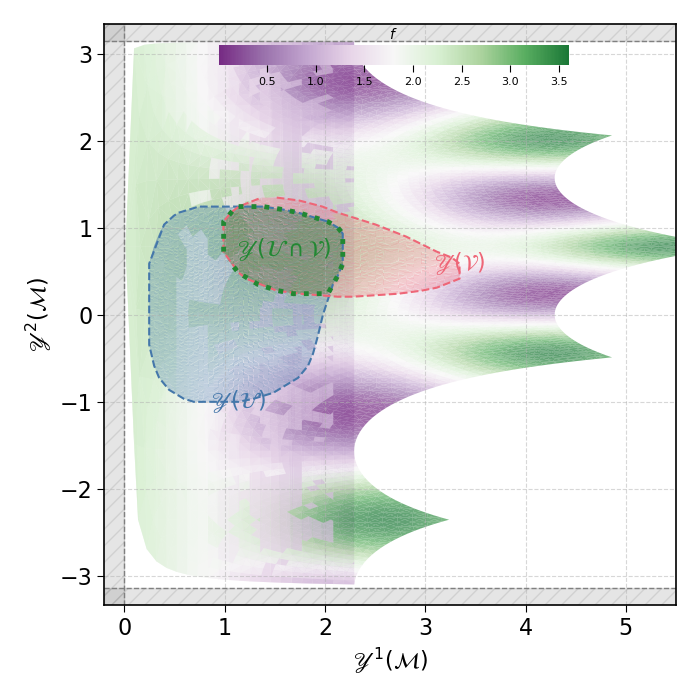

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))

x = jnp.linspace(xmin, xmax, 64)
y = jnp.linspace(ymin, ymax, 64)
x, y = jnp.meshgrid(x, y)
param_points = jnp.stack([x.ravel(), y.ravel()], axis=-1)
param_points = jnp.array(param_points)
# param_points = jnp.array(chart_V.sample_region_in_param_space(n_points=2**13))
function_values = jnp.array(function_f.evaluate_in_param_space(param_points))
tri = Delaunay(param_points)
plot_functions.plot_parametric_function_in_chart_coordinates(
    ax=ax, chart=chart_V, param_space_data=param_points, function_values=function_values, cmap=tc.PRGn,
    alpha=0.7, linewidth=0.01, label=None, label_position="top", label_fontsize=16,
    simplices=tri.simplices, inset_colorbar=True, inset_position=(0.2, 0.93), inset_size=(3.5, 0.2),
    colorbar_orientation="horizontal", label_colorbar=r"$f$", label_colorbar_position="top",
    inset_box_alpha=1.0, inset_box_color="white", inset_border_color="black"
)

param_points = jnp.array(chart_U.sample_region_in_param_space(n_points=2**13))
tri = Delaunay(param_points)
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_V, param_space_data=param_points, color=colors[0], linestyle="dashed",
    linewidth=1.5, alpha=0.3, label=r"$\mathscr{Y}(\mathcal{U})$", label_position="bottom",
    label_fontsize=16, tessellated=True, simplices=tri.simplices, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color=colors[0], boundary_marker_size=8
)
param_points = jnp.array(chart_V.sample_region_in_param_space(n_points=2**13))
tri = Delaunay(param_points)
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_V, param_space_data=param_points, color=colors[1], linestyle="dashed",
    linewidth=1.5, alpha=0.3, label=r"$\mathscr{Y}(\mathcal{V})$", label_position="right",
    label_fontsize=16, tessellated=True, simplices=tri.simplices, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color=colors[1], boundary_marker_size=8
)
param_points = jnp.array(chart_U_cap_V_X.sample_region_in_param_space(n_points=2**13))
tri = Delaunay(param_points)
plot_charts.plot_parametric_region_in_chart_coordinates(
    ax=ax, chart=chart_V, param_space_data=param_points, color=colors[2], linestyle="dotted",
    linewidth=3.5, alpha=0.3, label=r"$\mathscr{Y}(\mathcal{U} \cap \mathcal{V})$", label_position="center",
    label_fontsize=16, tessellated=True, simplices=tri.simplices, tessellation_edgecolor="none", tessellation_linewidth=0.1,
    mark_boundary_points=False, boundary_marker_color=colors[2], boundary_marker_size=8
)

ax.set(xlim=(-0.2, 5.5), ylim=(-jnp.pi-0.2, jnp.pi+0.2),
       xlabel=r"$\mathscr{Y}^1\left( \mathcal{M} \right)$", ylabel=r"$\mathscr{Y}^2\left( \mathcal{M} \right)$")
ax.axvspan(-1, 0, color='grey', alpha=0.2, hatch='//')
ax.axhspan(jnp.pi, jnp.pi+1, color='grey', alpha=0.2, hatch='//')
ax.axhspan(-jnp.pi-1, -jnp.pi, color='grey', alpha=0.2, hatch='//')
ax.axhline(jnp.pi, color='gray', ls='--', lw=1)
ax.axhline(-jnp.pi, color='gray', ls='--', lw=1)
ax.axvline(0, color='gray', ls='--', lw=1)
ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()